# Coding Assistant with Human-in-the-Loop Review

This notebook demonstrates a **Human-in-the-Loop (HITL)** workflow where:
1. AI generates Python code based on a task
2. **Human reviews and approves/edits** the code (INTERRUPT)
3. AI generates unit tests for the approved code

The key feature is the `interrupt()` function that **pauses execution** and waits for human input.

## Cell 1: Load Environment Variables

In [1]:
from dotenv import load_dotenv
import os

# Load environment variables (override=True to use .env file over system env)
load_dotenv(override=True)

# Verify API key is loaded
api_key = os.getenv('OPENAI_API_KEY')
if api_key:
    print(f"✓ OpenAI API Key loaded: {api_key[:15]}...{api_key[-5:]}")
else:
    print("✗ OpenAI API Key NOT found!")

✓ OpenAI API Key loaded: sk-proj-ZmDQs9m...aNL4A


## Cell 2: Import Libraries

In [4]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.types import interrupt, Command

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Cell 3: Define State Schema

In [6]:
class CodingAssistantState(TypedDict):
    task: str       # The coding task description
    code: str       # Generated Python code
    tests: str      # Generated unit tests

print("✓ State schema defined:")
print("  - task: str (coding task description)")
print("  - code: str (generated Python code)")
print("  - tests: str (generated unit tests)")

✓ State schema defined:
  - task: str (coding task description)
  - code: str (generated Python code)
  - tests: str (generated unit tests)


## Cell 4: Setup LLM and Chains

In [8]:
# Initialize the LLM
model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

# Define prompts
code_prompt = ChatPromptTemplate.from_template(
    "Generate Python code for the following task. Only provide the code, no explanations:\n\n{task}"
)
test_prompt = ChatPromptTemplate.from_template(
    "Write comprehensive unit tests for this Python code:\n\n{code}"
)

# Create chains
code_chain = code_prompt | model | StrOutputParser()
test_chain = test_prompt | model | StrOutputParser()

print("✓ LLM and chains configured")
print("  - code_chain: Task → Python Code")
print("  - test_chain: Code → Unit Tests")

✓ LLM and chains configured
  - code_chain: Task → Python Code
  - test_chain: Code → Unit Tests


## Cell 5: Define Node Functions

In [10]:
def generate_code(state) -> Command[Literal["human_review"]]:
    """Node 1: Generate Python code using LLM"""
    print("[NODE] generate_code - Generating Python code...")
    code = code_chain.invoke({"task": state["task"]})
    print("[NODE] generate_code - Code generated successfully!")
    return Command(goto="human_review", update={"code": code})


def human_review(state) -> Command[Literal["create_tests"]]:
    """Node 2: Pause for human review using interrupt()"""
    print("[NODE] human_review - Requesting human review...")
    
    # INTERRUPT: This pauses execution and waits for human input!
    human_response = interrupt({
        "message": "Please review the generated code below.",
        "code": state["code"],
        "instructions": "Respond with: {'action': 'approve'} or {'action': 'edit', 'edited_code': '...'}"
    })
    
    print(f"[NODE] human_review - Received response: {human_response}")
    
    # Process human response
    if human_response.get("action") == "edit" and "edited_code" in human_response:
        print("[NODE] human_review - Using edited code from human")
        return Command(goto="create_tests", update={"code": human_response["edited_code"]})
    else:
        print("[NODE] human_review - Code approved, proceeding to tests")
        return Command(goto="create_tests")


def create_tests(state) -> Command[Literal["__end__"]]:
    """Node 3: Generate unit tests for the code"""
    print("[NODE] create_tests - Generating unit tests...")
    tests = test_chain.invoke({"code": state["code"]})
    print("[NODE] create_tests - Tests generated successfully!")
    return Command(goto=END, update={"tests": tests})


print("✓ Node functions defined:")
print("  1. generate_code - LLM generates Python code")
print("  2. human_review - PAUSES for human approval (interrupt)")
print("  3. create_tests - LLM generates unit tests")

✓ Node functions defined:
  1. generate_code - LLM generates Python code
  2. human_review - PAUSES for human approval (interrupt)
  3. create_tests - LLM generates unit tests


## Cell 6: Build and Compile the Workflow

In [12]:
def create_coding_assistant_workflow():
    workflow = StateGraph(CodingAssistantState)
    
    # Add nodes
    workflow.add_node("generate_code", generate_code)
    workflow.add_node("human_review", human_review)
    workflow.add_node("create_tests", create_tests)
    
    # Set entry point
    workflow.set_entry_point("generate_code")
    
    # IMPORTANT: MemorySaver is required for interrupt() to work!
    # It saves the graph state when paused so it can resume later
    return workflow.compile(checkpointer=MemorySaver())


# Create the workflow
coding_assistant = create_coding_assistant_workflow()

print("✓ Workflow compiled with MemorySaver checkpointer")
print("\n  Flow: generate_code → human_review (INTERRUPT) → create_tests → END")

✓ Workflow compiled with MemorySaver checkpointer

  Flow: generate_code → human_review (INTERRUPT) → create_tests → END


## Cell 7: Visualize the Workflow

CODING ASSISTANT WORKFLOW


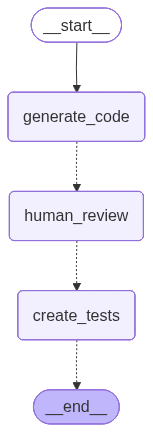

In [14]:
from IPython.display import Image, display

print("=" * 60)
print("CODING ASSISTANT WORKFLOW")
print("=" * 60)

try:
    display(Image(coding_assistant.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph: {e}")
    print("\nMermaid syntax:")
    print(coding_assistant.get_graph().draw_mermaid())

## Cell 8: STEP 1 - Start the Workflow (Will Pause at Human Review)

This cell starts the workflow. It will:
1. Generate code using the LLM
2. **PAUSE** at the human_review node and wait for your input

The graph will NOT continue until you run the next cell to provide your response.

In [16]:
# Define the coding task
task = "Create a function to reverse a string in Python."

# Input state
inputs = {"task": task}

# Thread ID - IMPORTANT: This identifies your session for checkpointing
# Use a unique ID for each new conversation
thread_config = {"configurable": {"thread_id": "coding-session-001"}}

print("=" * 60)
print("STEP 1: Starting Workflow")
print("=" * 60)
print(f"\nTask: {task}")
print(f"Thread ID: coding-session-001")
print("\n" + "-" * 60)

# Start the workflow - it will PAUSE at human_review
result = coding_assistant.invoke(inputs, config=thread_config)

print("\n" + "-" * 60)

STEP 1: Starting Workflow

Task: Create a function to reverse a string in Python.
Thread ID: coding-session-001

------------------------------------------------------------
[NODE] generate_code - Generating Python code...
[NODE] generate_code - Code generated successfully!
[NODE] human_review - Requesting human review...

------------------------------------------------------------


## Cell 9: Check Interrupt Status

This cell shows what the graph is waiting for.

In [24]:
print("=" * 60)
print("INTERRUPT STATUS")
print("=" * 60)

if "__interrupt__" in result:
    interrupt_info = result["__interrupt__"][0].value
    
    print("\n⏸️  GRAPH IS PAUSED - Waiting for human input!")
    print("\n" + "-" * 60)
    print("MESSAGE:", interrupt_info.get("message", ""))
    print("\n" + "-" * 60)
    print("GENERATED CODE:")
    print("\n" + interrupt_info.get("code", ""))
    print("\n" + "-" * 60)
    print("INSTRUCTIONS:", interrupt_info.get("instructions", ""))
    print("\n" + "=" * 60)
    print("\n>>> Run the NEXT CELL to approve or edit the code <<<")
else:
    print("\n✓ No interrupt - workflow completed or not started")
    print(f"\nResult: {result}")

INTERRUPT STATUS

⏸️  GRAPH IS PAUSED - Waiting for human input!

------------------------------------------------------------
MESSAGE: Please review the generated code below.

------------------------------------------------------------
GENERATED CODE:

def reverse_string(input_string):
    return input_string[::-1]

------------------------------------------------------------
INSTRUCTIONS: Respond with: {'action': 'approve'} or {'action': 'edit', 'edited_code': '...'}


>>> Run the NEXT CELL to approve or edit the code <<<


## Cell 10: STEP 2 - Provide Human Response (APPROVE)

Run this cell to **APPROVE** the generated code and continue the workflow.

In [28]:
print("=" * 60)
print("STEP 2: Human Response - APPROVE")
print("=" * 60)

# Resume with approval
human_response = {"action": "edit"}

print(f"\nSending response: {human_response}")
print("\n" + "-" * 60)

# Resume the workflow with Command(resume=...)
final_result = coding_assistant.invoke(
    Command(resume=human_response),
    config=thread_config
)

print("\n" + "=" * 60)
print("WORKFLOW COMPLETED!")
print("=" * 60)

STEP 2: Human Response - APPROVE

Sending response: {'action': 'edit'}

------------------------------------------------------------

WORKFLOW COMPLETED!


## Cell 11: View Final Results

In [30]:
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print("\n📋 TASK:")
print(final_result.get("task", "N/A"))

print("\n" + "-" * 60)
print("💻 GENERATED CODE:")
print(final_result.get("code", "No code generated"))

print("\n" + "-" * 60)
print("🧪 GENERATED TESTS:")
print(final_result.get("tests", "No tests generated"))

FINAL RESULTS

📋 TASK:
Create a function to reverse a string in Python.

------------------------------------------------------------
💻 GENERATED CODE:
def reverse_string(input_string):
    return input_string[::-1]

------------------------------------------------------------
🧪 GENERATED TESTS:
import unittest

def reverse_string(input_string):
    return input_string[::-1]

class TestReverseString(unittest.TestCase):
    
    def test_reverse_string(self):
        self.assertEqual(reverse_string("hello"), "olleh")
        self.assertEqual(reverse_string("12345"), "54321")
        self.assertEqual(reverse_string("python"), "nohtyp")
        self.assertEqual(reverse_string(""), "")
        self.assertEqual(reverse_string("a"), "a")
        self.assertEqual(reverse_string("racecar"), "racecar")
        
    def test_reverse_string_edge_cases(self):
        self.assertEqual(reverse_string(" "), " ")
        self.assertEqual(reverse_string("1234567890"), "0987654321")
        self.assertE

---

## Alternative: STEP 2 - Provide Human Response (EDIT)

If you want to **EDIT** the code instead of approving, run this cell instead of Cell 10.

**Note:** You need to restart from Cell 8 first to get a fresh interrupt.

In [32]:
# ALTERNATIVE: Edit the code before generating tests
# Only run this if you want to provide edited code

print("=" * 60)
print("STEP 2 (ALTERNATIVE): Human Response - EDIT")
print("=" * 60)

# Your edited code
edited_code = '''
def reverse_string(s: str) -> str:
    """Reverse a string.
    
    Args:
        s: The input string to reverse
        
    Returns:
        The reversed string
    """
    return s[::-1]
'''

# Resume with edited code
human_response = {
    "action": "edit",
    "edited_code": edited_code
}

print(f"\nSending response with edited code...")
print("\n" + "-" * 60)

# Resume the workflow
final_result = coding_assistant.invoke(
    Command(resume=human_response),
    config=thread_config
)

print("\n" + "=" * 60)
print("WORKFLOW COMPLETED WITH EDITED CODE!")
print("=" * 60)

STEP 2 (ALTERNATIVE): Human Response - EDIT

Sending response with edited code...

------------------------------------------------------------

WORKFLOW COMPLETED WITH EDITED CODE!


---

## Try a New Task

To try a different coding task, run this cell with a **new thread_id**.

In [35]:
# NEW TASK with a NEW thread_id
new_task = "Create a function to check if a number is prime."
new_thread_config = {"configurable": {"thread_id": "coding-session-002"}}

print("=" * 60)
print("NEW TASK")
print("=" * 60)
print(f"\nTask: {new_task}")
print(f"Thread ID: coding-session-002")
print("\n" + "-" * 60)

# Start new workflow
new_result = coding_assistant.invoke({"task": new_task}, config=new_thread_config)

print("\n" + "-" * 60)

# Check interrupt
if "__interrupt__" in new_result:
    print("\n⏸️  PAUSED - Review the code above")
    print("\nGenerated Code:")
    print(new_result["__interrupt__"][0].value.get("code", ""))

NEW TASK

Task: Create a function to check if a number is prime.
Thread ID: coding-session-002

------------------------------------------------------------
[NODE] generate_code - Generating Python code...
[NODE] generate_code - Code generated successfully!
[NODE] human_review - Requesting human review...

------------------------------------------------------------

⏸️  PAUSED - Review the code above

Generated Code:
def is_prime(num):
    if num < 2:
        return False
    for i in range(2, int(num**0.5) + 1):
        if num % i == 0:
            return False
    return True


In [37]:
# Approve the new task's code
new_final = coding_assistant.invoke(
    Command(resume={"action": "approve"}),
    config=new_thread_config
)

print("=" * 60)
print("NEW TASK COMPLETED!")
print("=" * 60)
print("\n💻 CODE:")
print(new_final.get("code", ""))
print("\n🧪 TESTS:")
print(new_final.get("tests", ""))

[NODE] human_review - Requesting human review...
[NODE] human_review - Received response: {'action': 'approve'}
[NODE] human_review - Code approved, proceeding to tests
[NODE] create_tests - Generating unit tests...
[NODE] create_tests - Tests generated successfully!
NEW TASK COMPLETED!

💻 CODE:
def is_prime(num):
    if num < 2:
        return False
    for i in range(2, int(num**0.5) + 1):
        if num % i == 0:
            return False
    return True

🧪 TESTS:
import unittest

class TestIsPrime(unittest.TestCase):

    def test_prime_number(self):
        self.assertTrue(is_prime(2))
        self.assertTrue(is_prime(3))
        self.assertTrue(is_prime(5))
        self.assertTrue(is_prime(7))
        self.assertTrue(is_prime(11))
        self.assertTrue(is_prime(13))
        self.assertTrue(is_prime(17))
        self.assertTrue(is_prime(19))
        self.assertTrue(is_prime(23))
        self.assertTrue(is_prime(29))

    def test_non_prime_number(self):
        self.assertFalse(i

## Summary

### Key Concepts Demonstrated:

| Concept | Description |
|---------|-------------|
| `interrupt()` | Pauses graph execution and waits for human input |
| `Command(resume=...)` | Resumes execution with human's response |
| `MemorySaver` | Checkpointer that saves state during interrupts |
| `thread_id` | Unique identifier for each conversation/session |

### Workflow:
1. **Cell 8**: Start workflow → generates code → PAUSES at human_review
2. **Cell 9**: Check what the graph is waiting for
3. **Cell 10**: Resume with approval (or Cell 12 to edit)
4. **Cell 11**: View final results

### Important:
- The graph **actually pauses** between Cell 8 and Cell 10
- You can close the notebook and resume later (state is saved)
- Use different `thread_id` for different conversations

In [ ]:
from typing import TypedDict
from psycopg import connect
from psycopg.rows import dict_row
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.postgres import PostgresSaver


DB_CONNECTION_STRING = "postgresql://localhost:5432/langgraph_memory"


# Define state format
class ChatState(TypedDict):
    messages: list


# Define tool for restaurant recommendations
@tool
def get_restaurant_recommendations(location: str):
    """Provides a single top restaurant recommendation for a given location."""
    recommendations = {
        "munich": ["Hofbräuhaus", "Augustiner-Keller", "Tantris"],
        "new york": ["Le Bernardin", "Eleven Madison Park", "Joe's Pizza"],
        "paris": ["Le Meurice", "L'Ambroisie", "Bistrot Paul Bert"],
    }
    return recommendations.get(location.lower(), ["No recommendations available."])[0]  # Return only the top recommendation


# Define tool for table booking
@tool
def book_table(restaurant: str, time: str):
    """Books a table at a specified restaurant and time."""
    return f"Table booked at {restaurant} for {time}."


# Bind tools to the model
tools = [get_restaurant_recommendations, book_table]
model = ChatOpenAI().bind_tools(tools)
tool_node = ToolNode(tools)


# Define function to invoke the model
def call_model(state: MessagesState):
    messages = state["messages"]
    response = model.invoke(messages)
    return {"messages": messages + [response]}  # Add response to the state


# Define conditional routing logic
def should_continue(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END


# Establish a database connection
with connect(DB_CONNECTION_STRING, autocommit=True, prepare_threshold=0, row_factory=dict_row) as conn:
    # TODO: Initialize Postgres-backed memory
    

    # Create the workflow graph
    workflow = StateGraph(MessagesState)

    workflow.add_node("agent", call_model)
    workflow.add_node("tools", tool_node)

    workflow.add_edge(START, "agent")
    workflow.add_conditional_edges("agent", should_continue)
    workflow.add_edge("tools", "agent")

    # TODO: Compile the graph with PostgreSQL-backed memory
    graph = workflow.compile(checkpointer=None)

    # Define configuration for memory
    config = {"configurable": {"thread_id": "1"}}

    # First invoke - Get one restaurant recommendation
    response = graph.invoke(
        {"messages": [HumanMessage(content="Can you recommend just one top restaurant in Paris? "
                                           "The response should contain just the restaurant name")]},
        config
    )

    # Extract the recommended restaurant from the response
    recommended_restaurant = response["messages"][-1].content
    print("Recommended restaurant:", recommended_restaurant)


    # Second invoke - Book a table at the recommended restaurant
    response = graph.invoke(
        {"messages": [HumanMessage(content=f"Book a table at this restaurant for 7 PM")]},
        config
    )

    # Extract the final response
    final_response = response["messages"][-1].content
    print("Final response:", final_response)
